In [230]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sts
from statsmodels.stats.multicomp import pairwise_tukeyhsd

**Лабораторная забота №3**

**Проверка статистических гипотез о виде и параметрах распределения случайных
величин.**

1. Используя данные Росстата, приведенные в файле данных CHISLO_DOCTORS.xlsx,
найти значения случайного показателя X : Число врачей на 10 тысяч человек
населения – в указанном в Вашем варианте Федеральном Округе в каждый год
периода T:2005, 2010, 2015, 2019, 2020 и 2021 гг.

Мой вариант: Сибирский ФО

Данные для всего ФО
: 51,6	52,4	47	48,8	49,2	49,4


In [231]:
# Данные
data = {
    "Регион": [
        "Республика Алтай",
        "Республика Тыва",
        "Республика Хакасия",
        "Алтайский край",
        "Красноярский край",
        "Иркутская область",
        "Кемеровская область",
        "Новосибирская область",
        "Омская область",
        "Томская область",
    ],
    "2005": [38.9, 42.8, 37.8, 46.7, 50.3, 47.5, 47.0, 61.7, 55.8, 67.3],
    "2010": [43.5, 45.6, 38.1, 48.7, 53.7, 49.9, 47.7, 58.3, 53.9, 69.1],
    "2015": [44.7, 48.9, 39.0, 42.9, 47.6, 45.5, 42.9, 51.6, 50.6, 53.5],
    "2019": [44.8, 49.7, 42.3, 42.6, 49.9, 49.0, 43.8, 54.6, 50.9, 56.4],
    "2020": [45.6, 50.6, 40.1, 43.4, 50.6, 49.2, 44.2, 56.0, 51.2, 53.1],
    "2021": [43.6, 50.2, 41.2, 43.0, 49.6, 49.6, 43.4, 56.7, 51.2, 59.3],
}

# Создаем DataFrame
df = pd.DataFrame(data)
#df=df.T
df.head(11)


,Регион,2005,2010,2015,2019,2020,2021
0,Республика Алтай,38.9,43.5,44.7,44.8,45.6,43.6
1,Республика Тыва,42.8,45.6,48.9,49.7,50.6,50.2
2,Республика Хакасия,37.8,38.1,39.0,42.3,40.1,41.2
3,Алтайский край,46.7,48.7,42.9,42.6,43.4,43.0
4,Красноярский край,50.3,53.7,47.6,49.9,50.6,49.6
5,Иркутская область,47.5,49.9,45.5,49.0,49.2,49.6
6,Кемеровская область,47.0,47.7,42.9,43.8,44.2,43.4
7,Новосибирская область,61.7,58.3,51.6,54.6,56.0,56.7
8,Омская область,55.8,53.9,50.6,50.9,51.2,51.2
9,Томская область,67.3,69.1,53.5,56.4,53.1,59.3


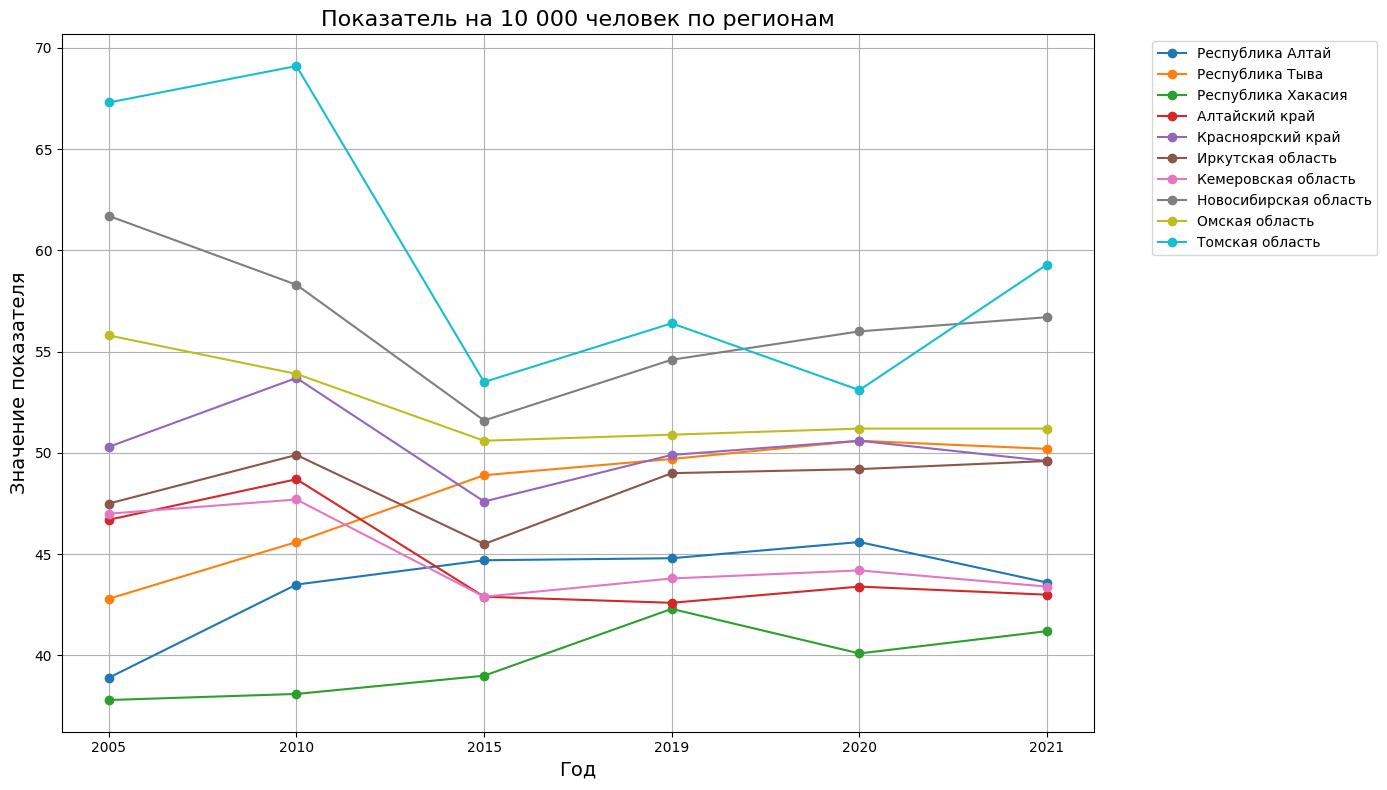

In [232]:
years = ["2005", "2010", "2015", "2019", "2020", "2021"]


plt.figure(figsize=(14, 8))


for i, region in enumerate(df["Регион"]):
    values = df.iloc[i, 1:].values
    plt.plot(years, values, marker="o", linestyle="-", label=region)


# Настройка графика
plt.title("Показатель на 10 000 человек по регионам", fontsize=16)
plt.xlabel("Год", fontsize=14)
plt.ylabel("Значение показателя", fontsize=14)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

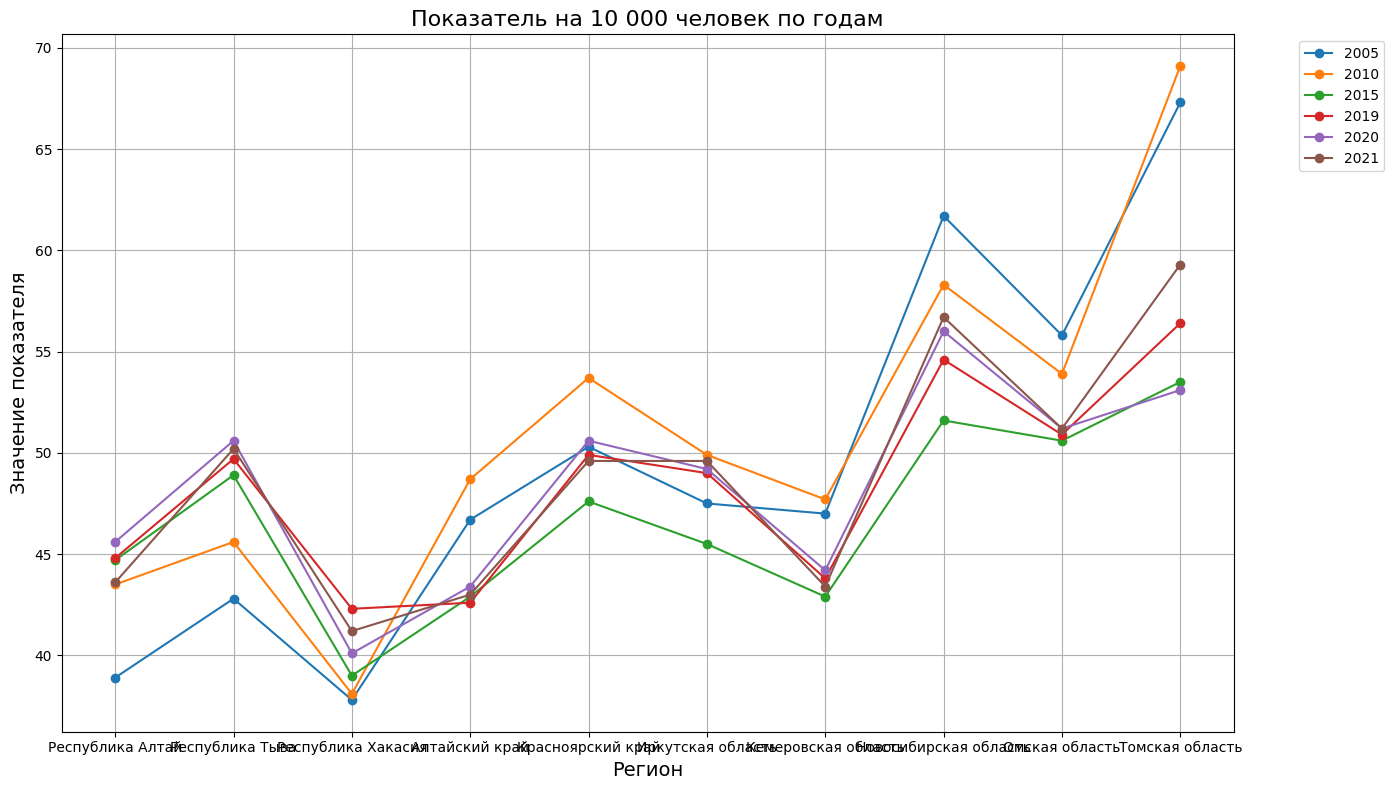

In [233]:
df_years = df.set_index("Регион").T 
df_years.index.name = "Год"

plt.figure(figsize=(14, 8))

for year in df_years.index: 
    values = df_years.loc[year].values
    plt.plot(df["Регион"], values, marker="o", linestyle="-", label=year)


plt.title("Показатель на 10 000 человек по годам", fontsize=16)
plt.xlabel("Регион", fontsize=14)
plt.ylabel("Значение показателя", fontsize=14)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

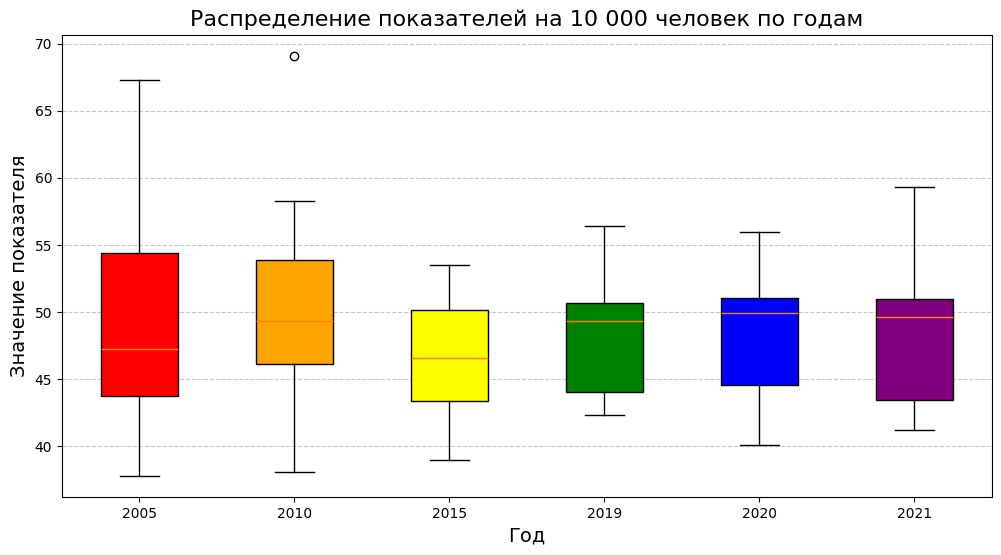

In [234]:
colors = ["red",  "orange", "yellow", "green", "blue", "purple",]

plt.figure(figsize=(12, 6))

box_data = [df[year] for year in df.columns[1:]]
bplot = plt.boxplot(box_data, labels=df.columns[1:], patch_artist=True)

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

# Настройки
plt.title("Распределение показателей на 10 000 человек по годам", fontsize=16)
plt.xlabel("Год", fontsize=14)
plt.ylabel("Значение показателя", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

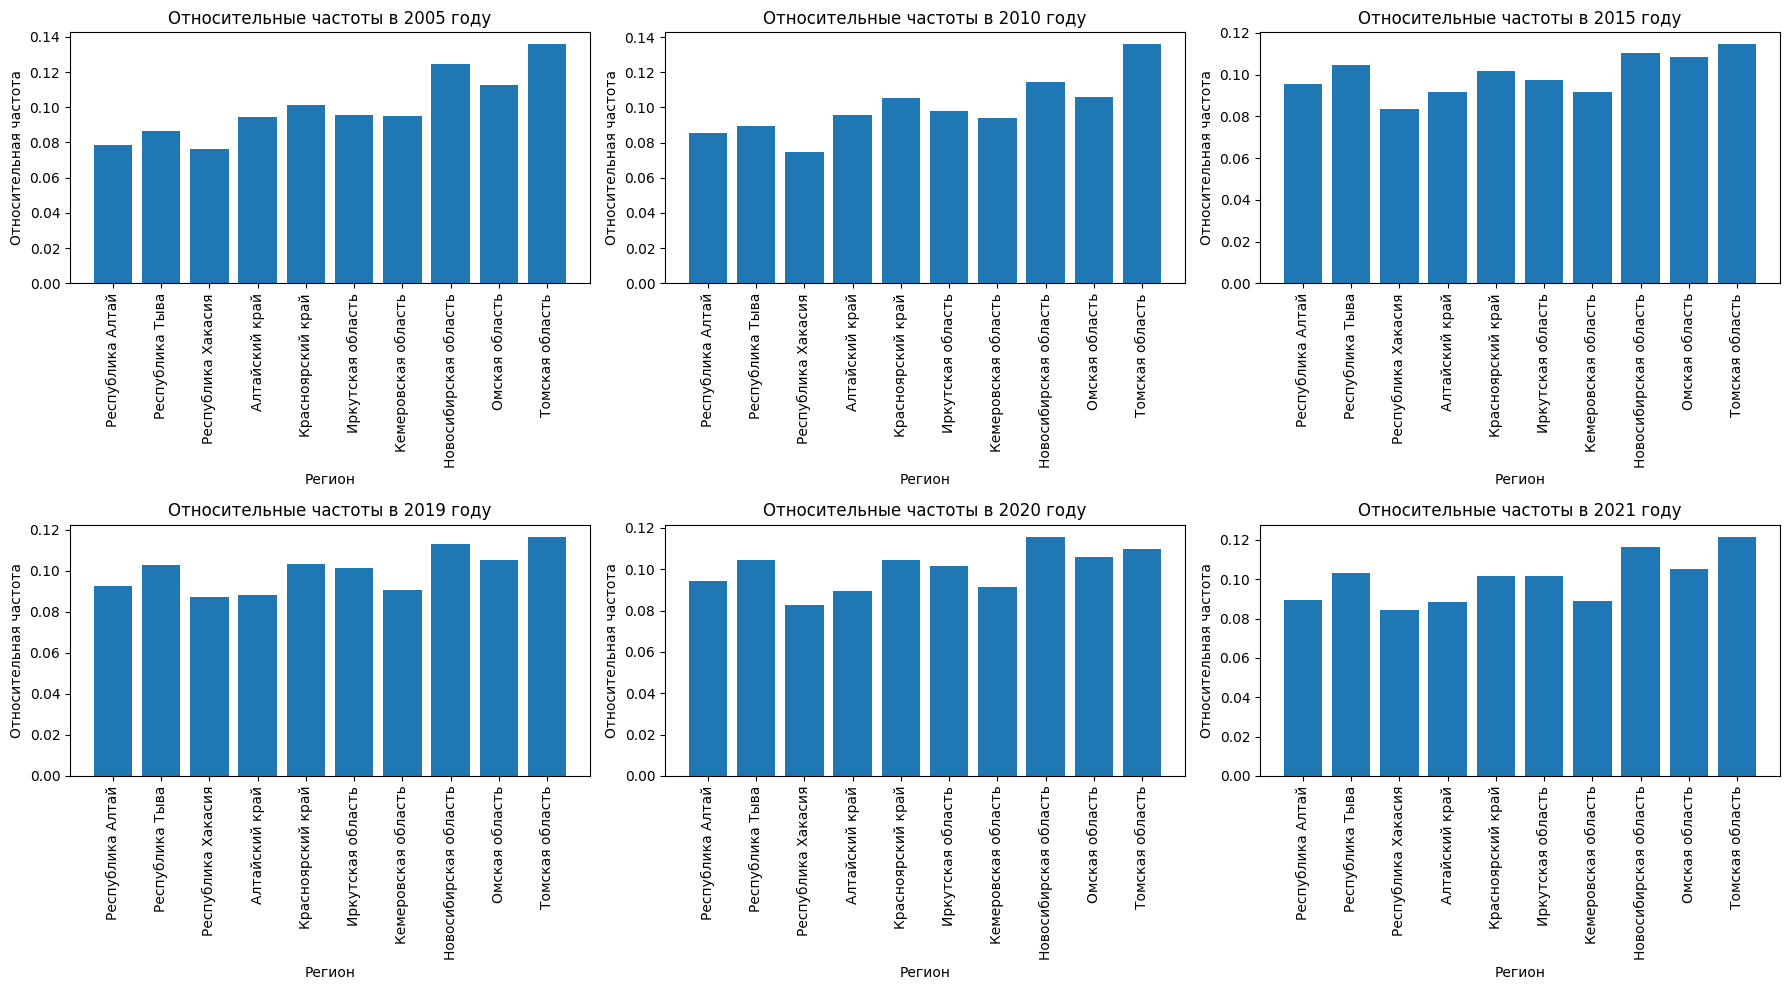

In [235]:
num_regions = len(df["Регион"])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, year in enumerate(years):
    values = df[year]
    total = sum(values)
    relative_frequencies = [value / total for value in values]
    
    axes[i].bar(data["Регион"], relative_frequencies)
    axes[i].set_title(f"Относительные частоты в {year} году")
    axes[i].set_xlabel("Регион")
    axes[i].set_ylabel("Относительная частота")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

3. Вычислить описательную статистику: среднее, стандартное отклонение, квартили,
минимальное и максимальное значения показателя X в каждый год периода T по
указанному в Вашем варианте Федеральному Округу.

In [236]:
#transposed_data = df.set_index(years).T
stats = df[years].describe()  

print("Описательная статистика по годам:")
print(stats)

Описательная статистика по годам:
            2005       2010       2015       2019       2020       2021
count  10.000000  10.000000  10.000000  10.000000  10.000000  10.000000
mean   49.580000  50.850000  46.720000  48.400000  48.400000  48.780000
std     9.534592   8.599645   4.530342   4.921156   4.914604   6.048471
min    37.800000  38.100000  39.000000  42.300000  40.100000  41.200000
25%    43.775000  46.125000  43.350000  44.050000  44.550000  43.450000
50%    47.250000  49.300000  46.550000  49.350000  49.900000  49.600000
75%    54.425000  53.850000  50.175000  50.650000  51.050000  50.950000
max    67.300000  69.100000  53.500000  56.400000  56.000000  59.300000


4. Проверить, можно ли считать, что распределение случайной величины X в указанном
Федеральном Округе в каждый год периода Т подчинено нормальному закону
распределения. Использовать для проверки тест Шапиро-Уилка (уровень значимости 0,03)

**Критерий Шапиро-Уилка**

Критерий Шапиро-Уилка основан на отношении оптимальной линейной несмещенной оценки дисперсии к ее обычной оценке методом максимального правдоподобия. 

In [237]:
alpha = 0.03
for i in years:
    data = df[i]
    
    stat, p_value = sts.stats.shapiro(data)

    print(f"Результаты теста Шапиро-Уилка для {i} года:")
    print(f"Статистика: {stat:.4f}")
    print(f"p-значение: {p_value:.4f}")

    if p_value > alpha:
        print("Гипотеза о нормальности принимается\n")
    else:
        print("Гипотеза о нормальности отклоняется\n")
    

Результаты теста Шапиро-Уилка для 2005 года:
Статистика: 0.9360
p-значение: 0.5097
Гипотеза о нормальности принимается

Результаты теста Шапиро-Уилка для 2010 года:
Статистика: 0.9555
p-значение: 0.7331
Гипотеза о нормальности принимается

Результаты теста Шапиро-Уилка для 2015 года:
Статистика: 0.9766
p-значение: 0.9446
Гипотеза о нормальности принимается

Результаты теста Шапиро-Уилка для 2019 года:
Статистика: 0.9268
p-значение: 0.4176
Гипотеза о нормальности принимается

Результаты теста Шапиро-Уилка для 2020 года:
Статистика: 0.9650
p-значение: 0.8412
Гипотеза о нормальности принимается

Результаты теста Шапиро-Уилка для 2021 года:
Статистика: 0.9167
p-значение: 0.3305
Гипотеза о нормальности принимается



Вывод: на заданном уровне значимости распределение случайного показателя можно считать нормальным на протяжении всего временного периода.

5. Выделить те года t1-tm с нормально распределенными значениями рядов данных Xt1-
Xtm, где Xt1- Xtm имеют одинаковую дисперсию (уровень значимости взять равным 0,03).
Использовать для проверки нулевой гипотезы о равенстве дисперсий тесты Бартлетта и
Левена.

Тест Бартлетта предполагает, что данные имеют нормальное распределение.
Тест Левена не требует нормального распределения данных.

Чувствительность к отклонениям от нормальности:

Тест Бартлетта более чувствителен к отклонениям от нормальности распределения данных.
Тест Левена более устойчив к отклонениям от нормальности.
Робастность:

Тест Левена более робастен (устойчив) к нарушениям предположений, таких как неравенство дисперсий и отклонения от нормальности.
Тест Бартлетта более чувствителен к нарушениям этих предположений.

Вычисления:

Тест Бартлетта основан на хи-квадрат распределении.
Тест Левена основан на F-распределении.

Применение:

Тест Бартлетта чаще используется, когда данные имеют нормальное распределение.
Тест Левена предпочтительнее, когда нормальность данных не гарантирована или когда предположение о нормальности может быть нарушено.

In [238]:
def check_levene_and_bartlett(df, alpha):
    if len(years) > 1:
        values_for_bartlett = [df[year].values for year in years]
        stat_bartlett, p_value_bartlett = sts.stats.bartlett(*values_for_bartlett)
        
        stat_levene, p_value_levene = sts.stats.levene(*values_for_bartlett)
        
        print(f"Результаты теста Бартлетта: Статистика = {stat_bartlett:.4f}, p-значение = {p_value_bartlett:.4f}")
        print(f"Результаты теста Левена: Статистика = {stat_levene:.4f}, p-значение = {p_value_levene:.4f}")
        
        if p_value_bartlett > alpha:
            print("Гипотеза о равенстве дисперсий принимается по тесту Бартлетта.")
        else:
            print("Гипотеза о равенстве дисперсий отклоняется по тесту Бартлетта.")
        
        if p_value_levene > alpha:
            print("Гипотеза о равенстве дисперсий принимается по тесту Левена.")
        else:
            print("Гипотеза о равенстве дисперсий отклоняется по тесту Левена.")
    else:
        print("Для проверки равенства дисперсий недостаточно данных (не более одного нормального года).")


In [239]:
check_levene_and_bartlett(df, 0.03)

Результаты теста Бартлетта: Статистика = 8.9857, p-значение = 0.1096
Результаты теста Левена: Статистика = 0.9523, p-значение = 0.4552
Гипотеза о равенстве дисперсий принимается по тесту Бартлетта.
Гипотеза о равенстве дисперсий принимается по тесту Левена.


6. Проверить, можно ли считать, что среднее значение показателя X по данному
Федеральному Округу в каждый год периода t1-tm значимо выше (ниже)
общероссийского значения показателя X (уровень значимости взять равным 0.03).
Общероссийские значения показателя X найти в файле CHISLO_DOCTORS.xlsx.
Использовать для проверки гипотезы о равенстве средних t-тест для одной выборки.

In [240]:
russian_values = [48.6, 50.1, 45.9, 48.7, 50.4, 51] 
rus_df = pd.DataFrame([russian_values], columns=years)
rus_df


,2005,2010,2015,2019,2020,2021
0,48.6,50.1,45.9,48.7,50.4,51


In [241]:
for year in years:
    data = df[year]
    stat, p = sts.stats.ttest_1samp(data, rus_df[year].values[0])  
    print(f"Год: {year}")
    print(f"Статистика: {stat:.4f}")
    print(f"p-значение: {p_value:.4f}")
    if p < alpha:
        if stat > 0:
            print(f'Среднее значение показателя X в {year} году значимо выше общероссийского\n')
        else:
            print(f'Среднее значение показателя X в {year} году значимо ниже общероссийского\n')
    else:
        print(f'Среднее значение показателя X в {year} году не отличается от общероссийского\n')

Год: 2005
Статистика: 0.3250
p-значение: 0.3305
Среднее значение показателя X в 2005 году не отличается от общероссийского

Год: 2010
Статистика: 0.2758
p-значение: 0.3305
Среднее значение показателя X в 2010 году не отличается от общероссийского

Год: 2015
Статистика: 0.5724
p-значение: 0.3305
Среднее значение показателя X в 2015 году не отличается от общероссийского

Год: 2019
Статистика: -0.1928
p-значение: 0.3305
Среднее значение показателя X в 2019 году не отличается от общероссийского

Год: 2020
Статистика: -1.2869
p-значение: 0.3305
Среднее значение показателя X в 2020 году не отличается от общероссийского

Год: 2021
Статистика: -1.1607
p-значение: 0.3305
Среднее значение показателя X в 2021 году не отличается от общероссийского



7. Проверить, можно ли считать, что различия между средними значениями показателя
X по данному Федеральному Округу в какие-то два года из периода t1-tm незначимы,
появились случайно (уровень значимости взять равным 0.03). Использовать для проверки
гипотезы о равенстве средних t-тест для двух выборок.

In [242]:
for i in range(len(years)):
    for j in range(i + 1, len(years)):
        year1 = years[i]
        year2 = years[j]
        data1 = df[year1]
        data2 = df[year2]
        stat, p = sts.stats.ttest_ind(data1, data2, equal_var=False)
        print(f"Годы: {year1} и {year2}")
        print(f"Статистика: {stat:.4f}")
        print(f"p-значение: {p_value:.4f}")
        if p < alpha:
            print(f'Средние значения показателя X в {year1} и {year2} годах значимо отличаются\n')
        else:
            print(f'Средние значения показателя X в {year1} и {year2} годах не отличаются\n')

Годы: 2005 и 2010
Статистика: -0.3128
p-значение: 0.3305
Средние значения показателя X в 2005 и 2010 годах не отличаются

Годы: 2005 и 2015
Статистика: 0.8568
p-значение: 0.3305
Средние значения показателя X в 2005 и 2015 годах не отличаются

Годы: 2005 и 2019
Статистика: 0.3478
p-значение: 0.3305
Средние значения показателя X в 2005 и 2019 годах не отличаются

Годы: 2005 и 2020
Статистика: 0.3479
p-значение: 0.3305
Средние значения показателя X в 2005 и 2020 годах не отличаются

Годы: 2005 и 2021
Статистика: 0.2241
p-значение: 0.3305
Средние значения показателя X в 2005 и 2021 годах не отличаются

Годы: 2010 и 2015
Статистика: 1.3436
p-значение: 0.3305
Средние значения показателя X в 2010 и 2015 годах не отличаются

Годы: 2010 и 2019
Статистика: 0.7819
p-значение: 0.3305
Средние значения показателя X в 2010 и 2019 годах не отличаются

Годы: 2010 и 2020
Статистика: 0.7822
p-значение: 0.3305
Средние значения показателя X в 2010 и 2020 годах не отличаются

Годы: 2010 и 2021
Статистика: 0

8. Проверить значимость отличий средних в выбранной группе . Использовать для проверки гипотезы о равенстве средних групп тест
Тьюки и односторонний тест ANOVA.

**Тест Тьюки** — это статистический тест, который определяет, состоит ли выборка из групп, которые отличаются друг от друга. 

Каждое среднее сравнивается со средним всех других групп с помощью «Честной значимой разницы», которая показывает, насколько далеко друг от друга находятся группы. 

Тест рекомендуется для близких по размеру групп и проверяет только парные (но не комплексные) гипотезы. 

**Анализ дисперсии (ANOVA)** представляет собой статистический метод, используемый для сравнения средних значений трех и более групп. Метод позволяет определить, вызывают ли различия между группами статистически значимые различия в среднем значении зависимой переменной. ANOVA основана на количественных данных и предполагает нормальность распределения и гомогенность дисперсий между группами.

ANOVA не показывает, между какими именно группами есть различия, а лишь указывает на их наличие.
Чтобы выяснить, какие именно пары групп имеют значимые различия, нужен пост-хок-тест, например, Tukey HSD.

In [243]:
data_for_tukey = pd.DataFrame({
    'value': df.drop(columns='Регион').stack(),  # Значения показателей
    'group': df.columns[1:].repeat(df.shape[0])  # Группы (годы)
})
tukey_test=pairwise_tukeyhsd(data_for_tukey['value'], data_for_tukey['group'], alpha=alpha)
print(tukey_test)

Multiple Comparison of Means - Tukey HSD, FWER=0.03 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  2005   2010    -1.34 0.9888 -8.1232  5.4432  False
  2005   2015     2.55 0.8419 -4.2332  9.3332  False
  2005   2019      2.4 0.8728 -4.3832  9.1832  False
  2005   2020     8.81 0.0019  2.0268 15.5932   True
  2005   2021    11.45    0.0  4.6668 18.2332   True
  2010   2015     3.89 0.4692 -2.8932 10.6732  False
  2010   2019     3.74 0.5132 -3.0432 10.5232  False
  2010   2020    10.15 0.0002  3.3668 16.9332   True
  2010   2021    12.79    0.0  6.0068 19.5732   True
  2015   2019    -0.15    1.0 -6.9332  6.6332  False
  2015   2020     6.26 0.0558 -0.5232 13.0432  False
  2015   2021      8.9 0.0016  2.1168 15.6832   True
  2019   2020     6.41 0.0469 -0.3732 13.1932  False
  2019   2021     9.05 0.0013  2.2668 15.8332   True
  2020   2021     2.64 0.8216 -4.1432  9.4232  False
----------------------------------------------

На основании анализа можно сделать вывод, что в 2020 и 2021 годах средние значения значительно отличаются от предыдущих лет

In [244]:
stat_anova, p_anova= sts.stats.f_oneway(df["2005"], df["2010"], df["2015"], df["2019"], df["2020"], df["2021"])
print(f'Статистика ANOVA: {stat_anova}')
print(f'p-значение: {p_anova}')
if p_anova < alpha:
    print('Средние значения показателя X в разных годах значимо отличаются.')
else:
    print('Средние значения показателя X в разных годах не отличаются.')


Статистика ANOVA: 0.4197750745661966
p-значение: 0.8329397664232344
Средние значения показателя X в разных годах не отличаются.


<h4>Часть 2.<h4>


1. Проверить, можно ли считать, что распределение случайной величины X в указанном
Федеральном Округе за весь период Т подчинено нормальному закону распределения.
Использовать для проверки следующие три критерия:
Хи-квадрат, Шапиро-Уилка и критерий Д’Агостино


In [245]:
data_values = df.iloc[:, 1:].values.flatten()
data_values

array([38.9, 43.5, 44.7, 44.8, 45.6, 43.6, 42.8, 45.6, 48.9, 49.7, 50.6,
       50.2, 37.8, 38.1, 39. , 42.3, 40.1, 41.2, 46.7, 48.7, 42.9, 42.6,
       43.4, 43. , 50.3, 53.7, 47.6, 49.9, 50.6, 49.6, 47.5, 49.9, 45.5,
       49. , 49.2, 49.6, 47. , 47.7, 42.9, 43.8, 44.2, 43.4, 61.7, 58.3,
       51.6, 54.6, 56. , 56.7, 55.8, 53.9, 50.6, 50.9, 51.2, 51.2, 67.3,
       69.1, 53.5, 56.4, 53.1, 59.3])

In [246]:
stat, p_value = sts.stats.shapiro(data_values)
alpha = 0.03  # Задайте ваш уровень значимости
if p_value > alpha:
    print("Шапиро-Уилк: Данные подчиняются нормальному распределению (p-value =", p_value, ")")
else:
    print("Шапиро-Уилк: Данные не подчиняются нормальному распределению (p-value =", p_value, ")")

Шапиро-Уилк: Данные не подчиняются нормальному распределению (p-value = 0.019536874751366985 )


**Критерий Д’Агостино**

В данном критерии в качестве статистики для проверки нормальности распределения используется отношение оценки Даутона для стандартного отклонения к выборочному стандартному отклонению, оцененному методом максимального правдоподобия 

In [247]:
stat, p_value = sts.stats.normaltest(data_values)
if p_value > alpha:
    print("Д'Агостино: Данные подчиняются нормальному распределению (p-value =", p_value, ")")
else:
    print("Д'Агостино: Данные не подчиняются нормальному распределению (p-value =", p_value, ")")

Д'Агостино: Данные не подчиняются нормальному распределению (p-value = 0.00954088148279452 )


**Критерий согласия $\chi^2$ - Пирсона**

Данный критерий является одним из наиболее распространенных критериев проверки гипотез о виде закона распределения и позволяет проверить значимость расхождения эмпирических (наблюдаемых) и теоретических (ожидаемых) частот. Таким образом, данный критерий позволяет проверить гипотезу о принадлежности наблюдаемой выборки некоторому теоретическому закону. Можно сказать, что критерий является универсальным, так как позволяет проверить принадлежность выборочных значений практическому любому закону распределения.

Функция scipy.stats.chisquare выполняет расчет критерия хи-квадрат:

Наблюдаемые частоты (hist) — фактическое количество данных в каждом бине.
Ожидаемые частоты (expected) — предполагаемое распределение данных.

In [248]:
hist, bin_edges = np.histogram(data_values, bins='auto') 
expected = np.ones_like(hist) * len(data_values) / len(hist) 
chi2_stat, p_value = sts.stats.chisquare(hist, expected)

if p_value > alpha:
    print("Хи-квадрат: Данные подчиняются нормальному распределению (p-value =", p_value, ")")
else:
    print("Хи-квадрат: Данные не подчиняются нормальному распределению (p-value =", p_value, ")")

Хи-квадрат: Данные не подчиняются нормальному распределению (p-value = 1.8242871119546156e-05 )


2. Смоделировать M выборок объемом n из значений случайной величины X, имеющей
нормальное распределение с параметрами, указанными в Вашем варианте. На уровне
значимости 0.03 проверить для каждой выборки гипотезу о нормальном законе
распределения с помощью критериев Шапиро-Уилка и Д’Агостино. По результатам
моделирования M выборок вычислить оценку вероятности совершить ошибку первого
рода

In [249]:
a = 3  
sigma = 9 
sample_size = 75  
n_samples = 6000  
alpha = 0.03  

samples = [np.random.normal(a, sigma, sample_size) for i in range(n_samples)]

Выполним проверку гипотезы о нормальности каждой выборки с использованием критериев Шапиро-Уилка и Д'Агостино. Для каждого критерия будем фиксировать случаи, когда гипотеза отвергается (
𝑝
≤
𝛼):

In [250]:
shapiro_rejections = 0
dagostino_rejections = 0

for sample in samples:
    # Критерий Шапиро-Уилка
    stats, p = sts.stats.shapiro(sample)
    if p <= alpha:
        shapiro_rejections += 1

    # Критерий Д'Агостино
    stats, p_dagostino = sts.stats.normaltest(sample)
    if p_dagostino <= alpha:
        dagostino_rejections += 1

In [251]:
shapiro_error_rate = shapiro_rejections / n_samples
dagostino_error_rate = dagostino_rejections / n_samples

print(f"Оценка вероятности ошибки первого рода (Шапиро-Уилк): {shapiro_error_rate:.4f}")
print(f"Оценка вероятности ошибки первого рода (Д'Агостино): {dagostino_error_rate:.4f}")

Оценка вероятности ошибки первого рода (Шапиро-Уилк): 0.0307
Оценка вероятности ошибки первого рода (Д'Агостино): 0.0425


3. Смоделировать M выборок объемом n из значений случайной величины Y, имеющей распределение Лапласа
с параметром масштаба,
равным 2, и параметром
сдвига, равным 1. На уровне значимости  проверить для
каждой выборки гипотезу о нормальном законе распределения с помощью критериев
Шапиро-Уилка и Д’Агостино. Вычислить оценку вероятности не допустить ошибку
второго рода. Какой из критериев при данной альтернативе является более мощным?

In [252]:
samples = [sts.stats.laplace.rvs(loc=a, scale=2, size=75) for _ in range(6000)]

Проверяем каждую выборку на нормальность с помощью критериев Шапиро-Уилка и Д'Агостино:

In [253]:
shapiro_rejections = 0
dagostino_rejections = 0

for sample in samples:
    stat, p = sts.stats.shapiro(sample)
    if p <= alpha:
        shapiro_rejections += 1

    stat, p = sts.stats.normaltest(sample)
    if p <= alpha:
        dagostino_rejections += 1

Мощность критериев (
1−β) вычисляется как доля выборок, где гипотеза о нормальности отвергнута:

Мощность определяется как вероятность отвергнуть нулевую гипотезу, когда она ложна. Поэтому мощность равна 1 минус доля отклонений нулевой гипотезы.

In [254]:
shapiro_power = 1-(shapiro_rejections / 6000)
dagostino_power = 1-(dagostino_rejections / 6000)

print(f"Мощность критерия Шапиро-Уилка: {shapiro_power:.4f}")
print(f"Мощность критерия Д'Агостино: {dagostino_power:.4f}")

Мощность критерия Шапиро-Уилка: 0.3748
Мощность критерия Д'Агостино: 0.4237


Критерий Д'Агостино более чувствителен к асимметриям и крутизне, что делает его обычно более мощным при таких альтернативах.
Критерий Шапиро-Уилка эффективен для небольших выборок, но менее чувствителен к хвостам.